# 01 · Exploratory Data Analysis — Raw Data

**UC Berkeley Capstone — Predicting YouTube engagement relative to a channel's own baseline**

## Business understanding

For an individual creator, the first 24 hours after publishing a video are
decisive: if a video is not gaining traction early there is only a narrow window
to react (adjust the title or thumbnail, promote it, or re-upload). For a
platform, the same early signal informs recommendation seeding and creator
tooling.

**Research question.** *Can we predict whether a video will achieve
above-median engagement within 7 days of publication, using only signals
observable at upload time or within the first 24 hours?*

Engagement is defined as `(likes + comments) / views` at the 7-day mark,
benchmarked against **that channel's own historical median**. Because each video
is judged against its own channel, roughly 50% of any channel's videos land
above its median by construction — which makes the problem meaningful across
creators of any size and removes class imbalance from the outset.

## What this notebook covers

This notebook explores the **raw data volume** — the snapshot rows as collected,
and the cleaned per-video table that the modeling pipeline produces before any
feature engineering. It is re-run infrequently: the *nature* of the data does
not change between collection cycles, only its volume.

> **Sequence:** this is notebook 1 of 5. See [notebooks.md](./notebooks.md) for
> how the notebooks fit together.

## Configuration & guardrails

Every notebook in this sequence carries an **`IS_DRY_RUN`** guardrail (default
`True`). When `True`, no write operations occur — here that means EDA figures
are *not* saved to disk. `IS_DRY_RUN` is passed into `VersionConfig.dry_run(...)`
so the same switch governs every write across the sequence; the snapshotter
stages and `commit()` honor it centrally rather than each cell branching on it.

This notebook loads from the most recent **committed** GCS data snapshot (no
BigQuery call) and runs only the two stages needed to produce the raw per-video
table: `DataLoader` → `DataPreprocessor`.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda

IMAGES_FOLDER = "../../../images/eda/"

# Write new figure PNGs, but persist NO data. dry_run keeps its usual meaning here
# (no data written, existing version numbers, no bumps); SAVE_FIGURES separately
# controls image output. This notebook never writes to GCS regardless.
SAVE_FIGURES = True
PERSIST_DATA = False

def fig_path(name):
    return f"{IMAGES_FOLDER}{name}" if SAVE_FIGURES else None

config = VersionConfig.load().dry_run(not PERSIST_DATA).build()
run = PipelineRun(config)
stages = PipelineFactory.retrain_existing_data(config)

VersionConfig loaded:
  data:          v3.5 (raw_suffix='real')
  baselines:     v5.0
  model:         v6.2
  hyperparams:   v1.2
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.5 (unchanged)
  baselines         : v5.0 (unchanged)
  model             : v6.2 (unchanged)
  hyperparams       : v1.2 (unchanged)
  raw_version       : v3.5_real
  next_final_version: v3.5_100real
  model_version     : v6.2
  baselines_version : v5.0
  hyperparam_version: v1.2
  use_synthetic     : False
  dry_run           : True  (no GCS writes will occur)

  DRY RUN — set .dry_run(False) to persist artifacts and commit versions.


### Pipeline execution

`DataLoader` reads the parquet snapshot pinned in `config/versions.json`;
`DataPreprocessor` pivots the long-format poll rows into one wide row per video,
joins the per-channel baseline medians, and runs structural cleanup. We stop
here — no splitting, scaling, or modeling happens in this notebook.

In [2]:
stages.loader.run(run)
stages.preprocessor.run(run)
run.summary()

Loaded snapshot 'v3.5_real': 106626 rows from 2026-05-29
  Polls: {'upload': 37387, '24h': 36506, '7d': 32733}


Loaded baselines 'v5.0': 40841 baseline videos, 1375 median rows (1375 channels)
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 32571 (dropped 4864 incomplete)
  Pivoted shape: (32740, 34)

[2/3] Joining baseline medians...
  Baseline join: 32740/32740 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/failed harvest).
  Cleaned: 32725 rows × 40 columns

Clean dataset: 32725 rows × 40 columns
PipelineRun(config=VersionConfig(data=(3, 5), model=(6, 2), baselin

## Part 1 — Raw collection volume

The harvester records up to three labeled snapshots per video — `upload`
(within ~6h of publishing), `24h`, and `7d` — stored as separate rows in
long format (`run.df_videos`). Only videos with a **complete triplet** can be
modeled, because the growth-rate features require all three time points. The
cells below quantify the raw collection volume and how much survives the
complete-triplet requirement.

In [3]:
videos = run.df_videos
print(f"Raw snapshot rows:      {len(videos):,}")
print(f"Distinct videos:        {videos['video_id'].nunique():,}")
print(f"Distinct channels:      {videos['channel_id'].nunique():,}")
print(f"Collection window:      {videos['poll_timestamp'].min()}  ->  {videos['poll_timestamp'].max()}")
print("\nRows per poll label:")
print(videos["poll_label"].value_counts().to_string())

Raw snapshot rows:      106,626
Distinct videos:        37,435


Distinct channels:      1,226
Collection window:      2026-03-06 16:44:06.529262+00:00  ->  2026-05-29 22:05:05.921141+00:00

Rows per poll label:
poll_label
upload    37387
24h       36506
7d        32733


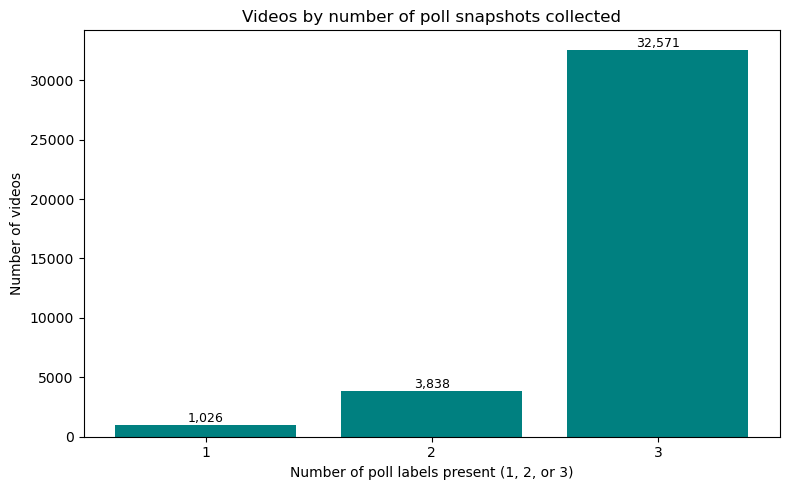

Complete triplets (modelable): 32,571 of 37,435 videos (87.0%)


In [4]:
# How many videos have all three poll labels (the modelable "complete triplets")?
polls_per_video = videos.groupby("video_id")["poll_label"].nunique()
triplet_counts = polls_per_video.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(triplet_counts.index.astype(str), triplet_counts.values, color="teal")
ax.set_title("Videos by number of poll snapshots collected")
ax.set_xlabel("Number of poll labels present (1, 2, or 3)")
ax.set_ylabel("Number of videos")
for x, y in zip(triplet_counts.index.astype(str), triplet_counts.values):
    ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
eda.save_fig(fig, fig_path("00_poll_completeness.png"))
plt.show()

complete = int((polls_per_video == 3).sum())
print(f"Complete triplets (modelable): {complete:,} of {videos['video_id'].nunique():,} videos "
      f"({complete / videos['video_id'].nunique():.1%})")

## Part 2 — Cleaned per-video table (`df_clean`)

`df_clean` is the output of `DataPreprocessor`: one wide row per complete-triplet
video, with raw engagement counts at each snapshot, the joined channel baseline
medians, and categorical metadata (`vertical`, `tier`). This is the table all
feature engineering builds on.

In [5]:
eda.set_active_df(run, run.df_clean)

df = run.active_eda_df
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nDtype breakdown:")
print(df.dtypes.value_counts().to_string())
df.describe()

Shape: 32,725 rows x 40 columns

Dtype breakdown:
Int64                  18
object                 11
float64                 6
datetime64[us, UTC]     4
boolean                 1


,duration_seconds,face_count,brightness,colorfulness,view_count_upload,like_count_upload,comment_count_upload,subscriber_count_upload,hours_since_publish_upload,view_count_24h,...,view_count_7d,like_count_7d,comment_count_7d,subscriber_count_7d,hours_since_publish_7d,baseline_baseline_video_count,baseline_median_views,baseline_median_likes,baseline_median_comments,baseline_median_engagement_rate
count,32725.0,32725.0,32725.000000,32725.000000,32725.0,32725.0,32725.0,32725.0,32725.000000,32725.0,...,32725.0,32725.0,32725.0,32725.0,32725.000000,32725.0,32725.0,32725.0,32725.0,32725.000000
mean,967.516914,0.872452,76.503501,42.920306,6134.073552,368.81974,24.79838,1501667.978915,4.091938,42274.859374,...,102743.810451,2644.319725,111.467166,1505549.767762,156.338088,29.120031,61483.813659,2034.779526,79.744079,0.036958
std,2803.049393,1.02567,28.387461,23.601194,31547.87503,1462.119533,99.986929,2341359.360501,93.614385,262330.385075,...,927710.607185,13341.276333,428.769077,2347657.841369,15.965880,3.108156,236422.397839,7577.76592,227.790345,0.026019
min,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1010.0,-0.020000,0.0,...,0.0,0.0,0.0,1020.0,0.090000,7.0,11.0,0.0,0.0,0.000000
25%,42.0,0.0,58.125069,25.349231,66.0,4.0,0.0,43900.0,1.020000,684.0,...,1131.0,26.0,1.0,44400.0,156.380000,30.0,1199.0,27.0,1.0,0.019402
50%,148.0,1.0,74.348096,37.684780,441.0,25.0,1.0,312000.0,2.070000,2997.0,...,5746.0,181.0,8.0,314000.0,157.090000,30.0,6151.0,186.0,7.0,0.030006
75%,933.0,1.0,91.861412,56.947023,2004.0,150.0,9.0,1820000.0,3.510000,14593.0,...,31516.0,989.0,53.0,1820000.0,158.070000,30.0,29057.0,902.0,47.0,0.050346
max,86134.0,14.0,228.163918,170.229322,1650228.0,52463.0,4587.0,10100000.0,12224.100000,26047103.0,...,105938940.0,904509.0,15102.0,10200000.0,2676.010000,30.0,4589046.0,135730.0,6000.0,0.200666


### Data quality — missing values & duplicates

This project does **not** impute. Incomplete records are handled structurally at
the stage that introduces the gap:

- videos without all three poll labels are dropped during the pivot;
- videos whose channel has no baseline median are dropped at the join;
- videos whose `contains_synthetic_media` flag is null are dropped during
  cleanup — a null there means the platform flag could not be retrieved,
  typically because the video was later made private or failed mid-harvest.
  These are few, so they are excluded rather than imputed.

The cells below confirm `df_clean` carries no remaining nulls and that
`video_id` is effectively unique.

In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
quality = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
quality = quality[quality["null_count"] > 0]

if quality.empty:
    print("No missing values detected in df_clean.")
else:
    print(f"Columns with nulls ({len(quality)}):")
    display(quality.sort_values("null_count", ascending=False))

n_dup = df.duplicated(subset="video_id").sum()
print(f"\nTotal rows: {len(df):,}  |  Unique video_ids: {df['video_id'].nunique():,}  |  Duplicate video_ids: {n_dup}")

No missing values detected in df_clean.



Total rows: 32,725  |  Unique video_ids: 32,556  |  Duplicate video_ids: 169


### Outlier analysis

Engagement metrics follow a power-law distribution: a few viral videos receive
orders of magnitude more views than the median. Standard IQR fences
(Q1 − 1.5·IQR, Q3 + 1.5·IQR) quantify how many rows fall outside the expected
range per feature.

**Decision: outliers are retained.** These are real observations, not data-entry
errors. Removing viral events would bias the dataset and distort the
channel-relative baseline that defines the target. The engineered ratio/growth
features compress extreme raw counts, and the tree models are robust to them. A
high `pct_outliers` on a raw count column is expected and is not a data-quality
problem.

In [7]:
exclude_ = {"video_id", "above_baseline", "is_short", "is_long"}
num_cols_ = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_]

rows_ = []
for col in num_cols_:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    rows_.append({
        "feature": col,
        "iqr": round(iqr, 3),
        "n_outliers": n_out,
        "pct_outliers": round(n_out / len(s) * 100, 2),
    })

pd.DataFrame(rows_).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

,feature,iqr,n_outliers,pct_outliers
0,comment_count_upload,9.000,5262,16.08
1,comment_count_24h,32.000,5103,15.59
2,view_count_7d,30385.000,5091,15.56
3,baseline_median_views,27858.000,5065,15.48
4,like_count_upload,146.000,5045,15.42
5,view_count_upload,1938.000,5031,15.37
6,baseline_median_likes,875.000,5028,15.36
7,comment_count_7d,52.000,5025,15.36
8,like_count_7d,963.000,4992,15.25
9,baseline_median_comments,46.000,4963,15.17


### Engagement metric distributions

Plain histograms across all continuous features in `df_clean`. The right skew is
the expected power-law signature of raw engagement counts; the long right tail is
the retained viral outliers. (KDE is omitted from the full grid for speed — see
the next cell for smoothed curves on the priority features.)

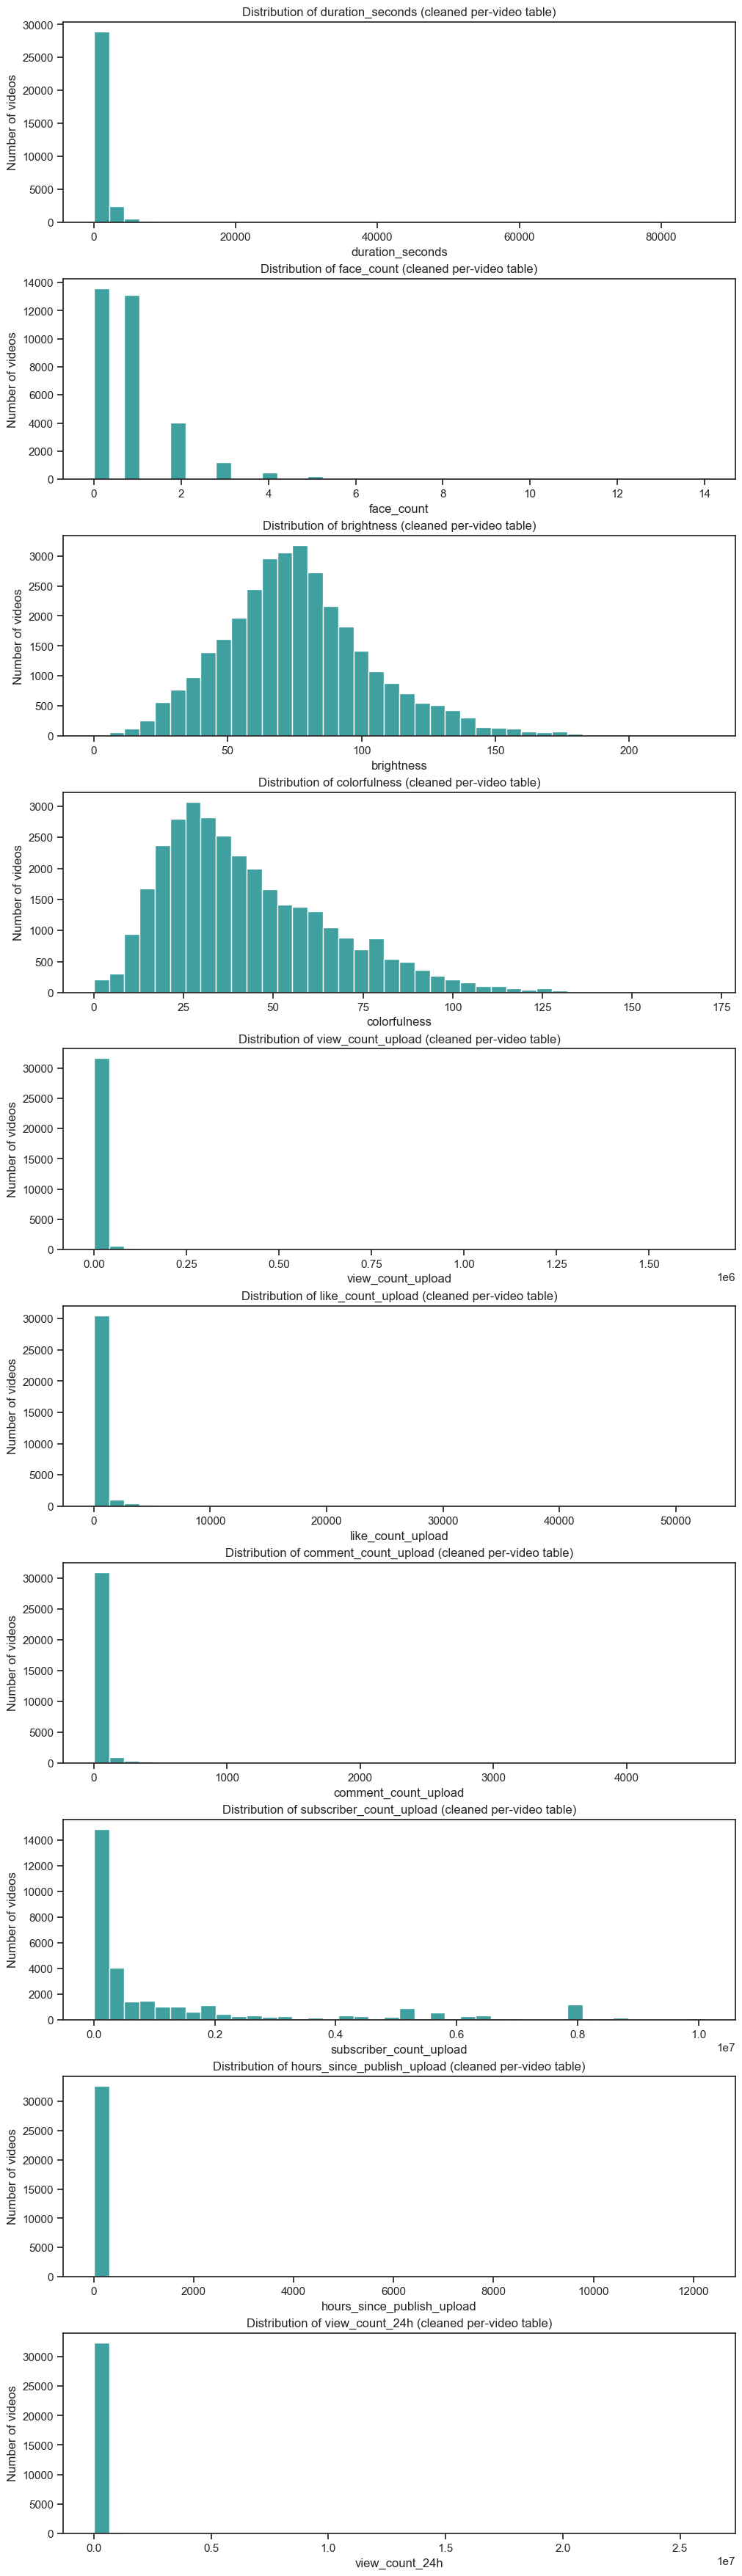

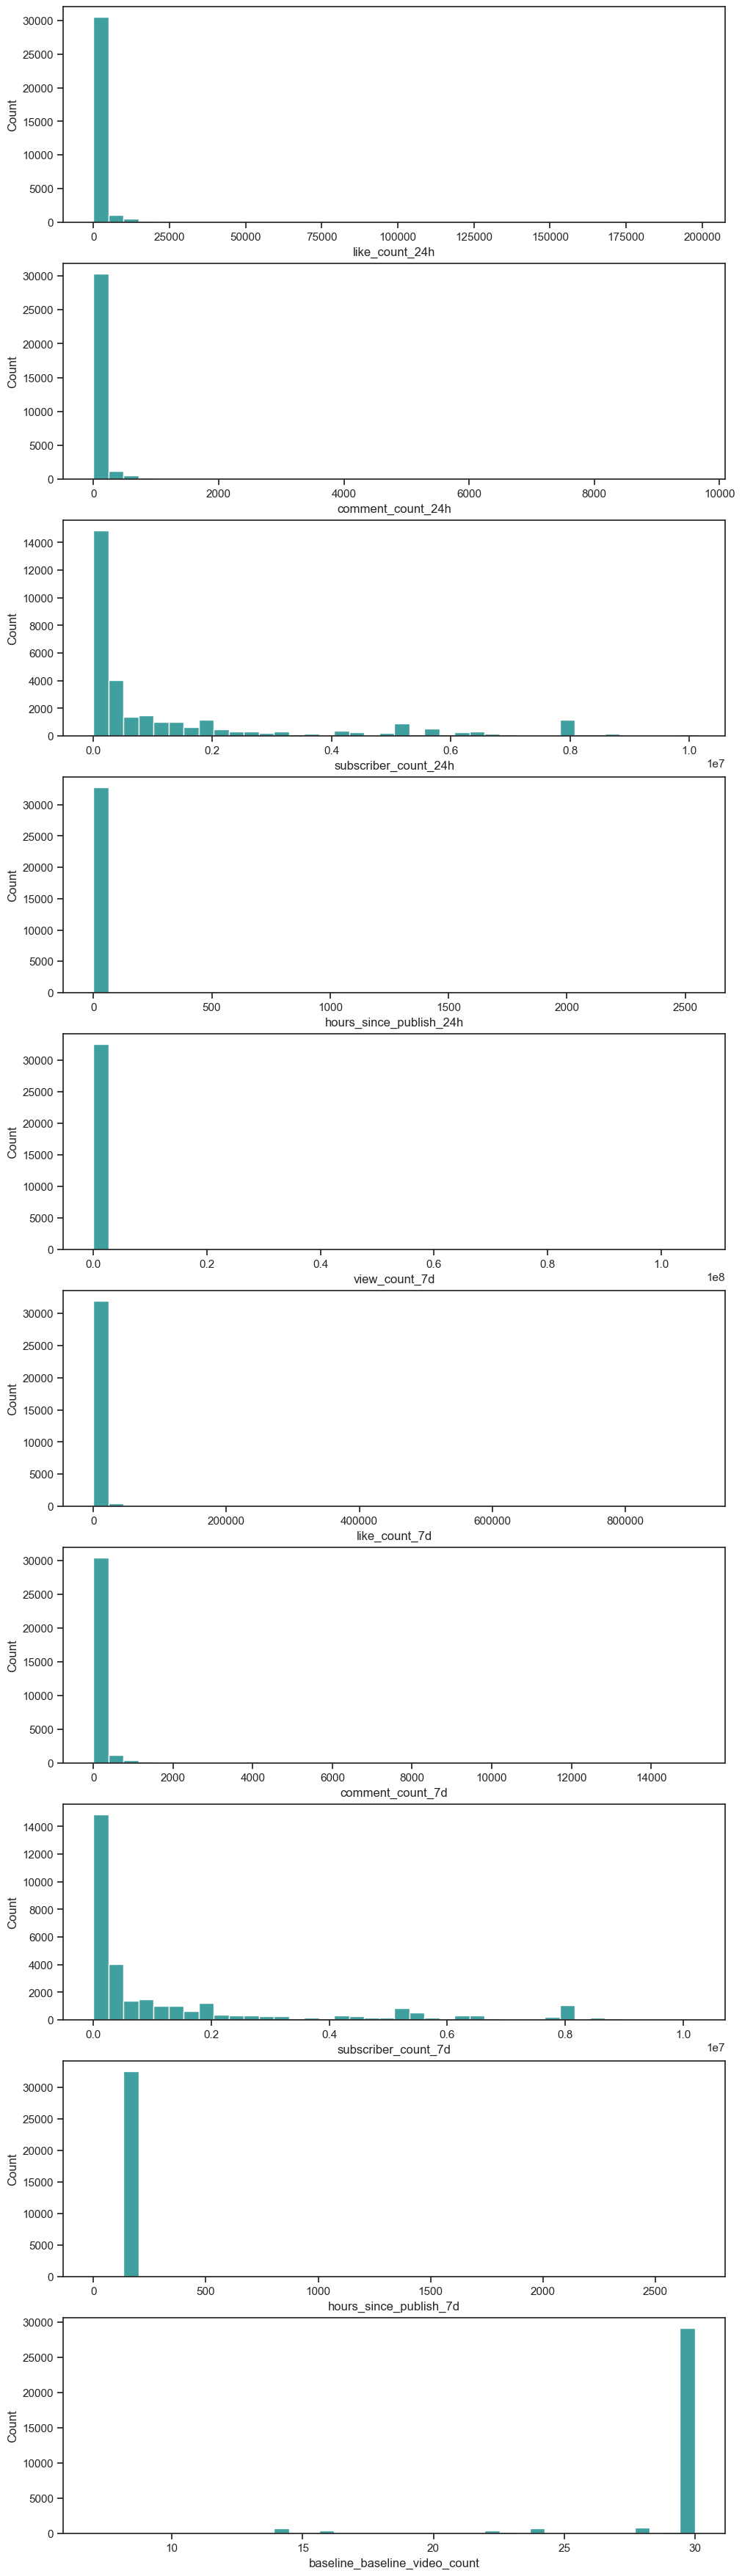

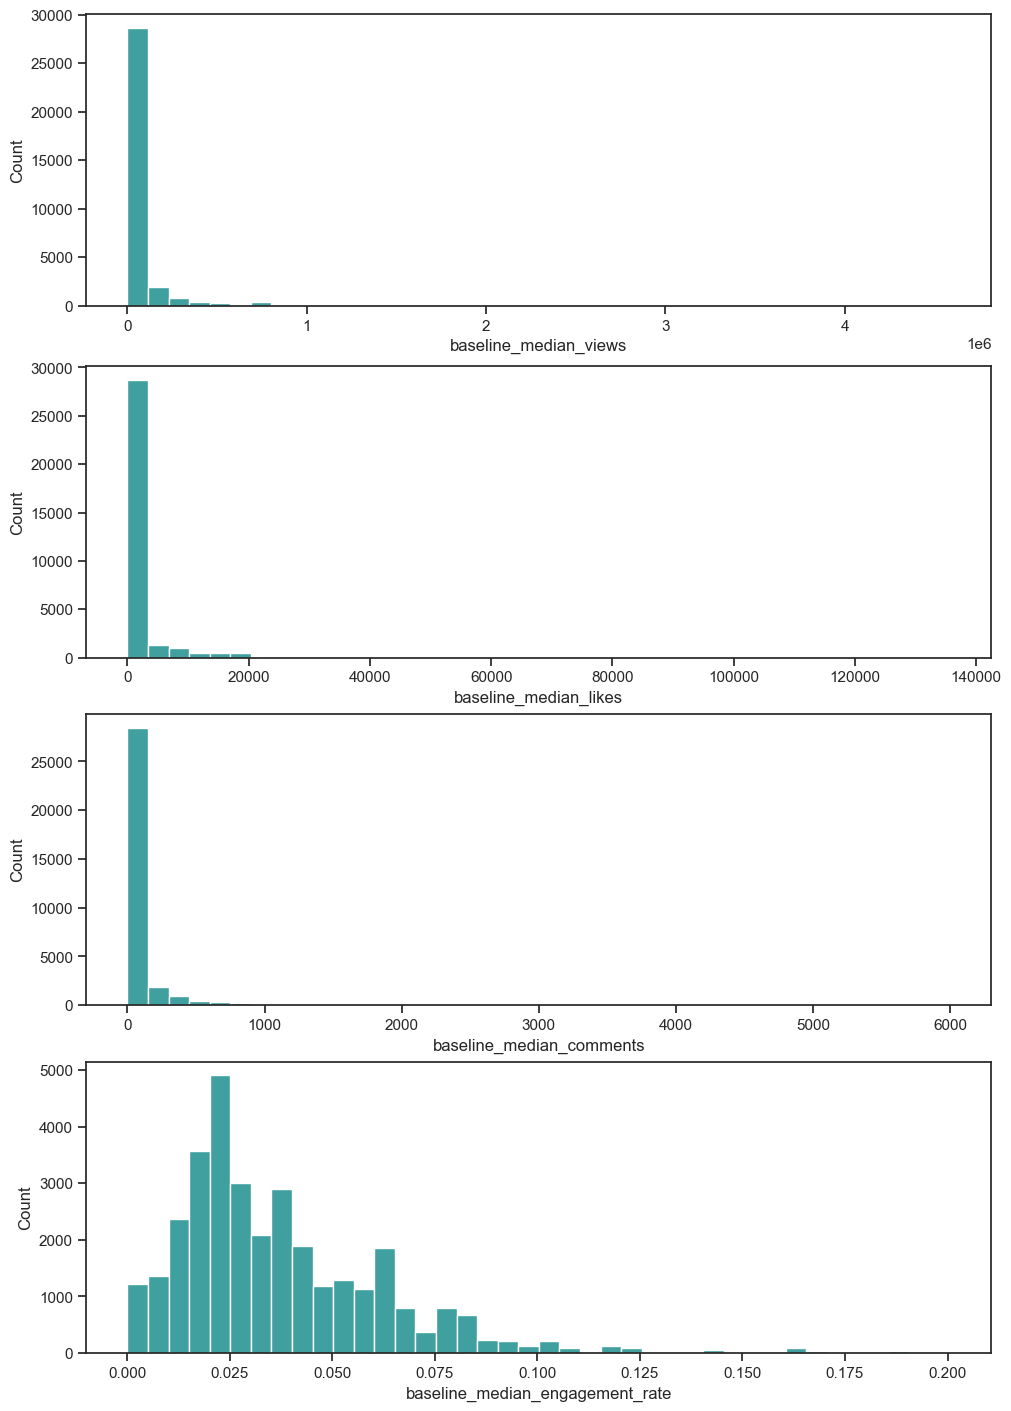

In [8]:
# plot_engagement_distribution() draws the paged histograms and returns one
# (fig, axes, cols) per page; the titles and axis labels are set here so they
# render on every subplot.
for page, (fig, axes, cols) in enumerate(eda.plot_engagement_distribution(run), start=1):
    for ax, col in zip(axes, cols):
        ax.set_title(f"Distribution of {col} (cleaned per-video table)")
        ax.set_xlabel(col)
        ax.set_ylabel("Number of videos")
    eda.save_fig(fig, fig_path("01_engagement_distributions.png"), page=page)
    plt.show()

### Priority engagement signals — with KDE

Smoothed density curves for the core engagement signals (the three snapshot view
counts plus 24h likes/comments). These anchor the target definition and the
growth-rate features. KDE is computed on a fixed 200-point grid, so it stays fast
regardless of dataset size.

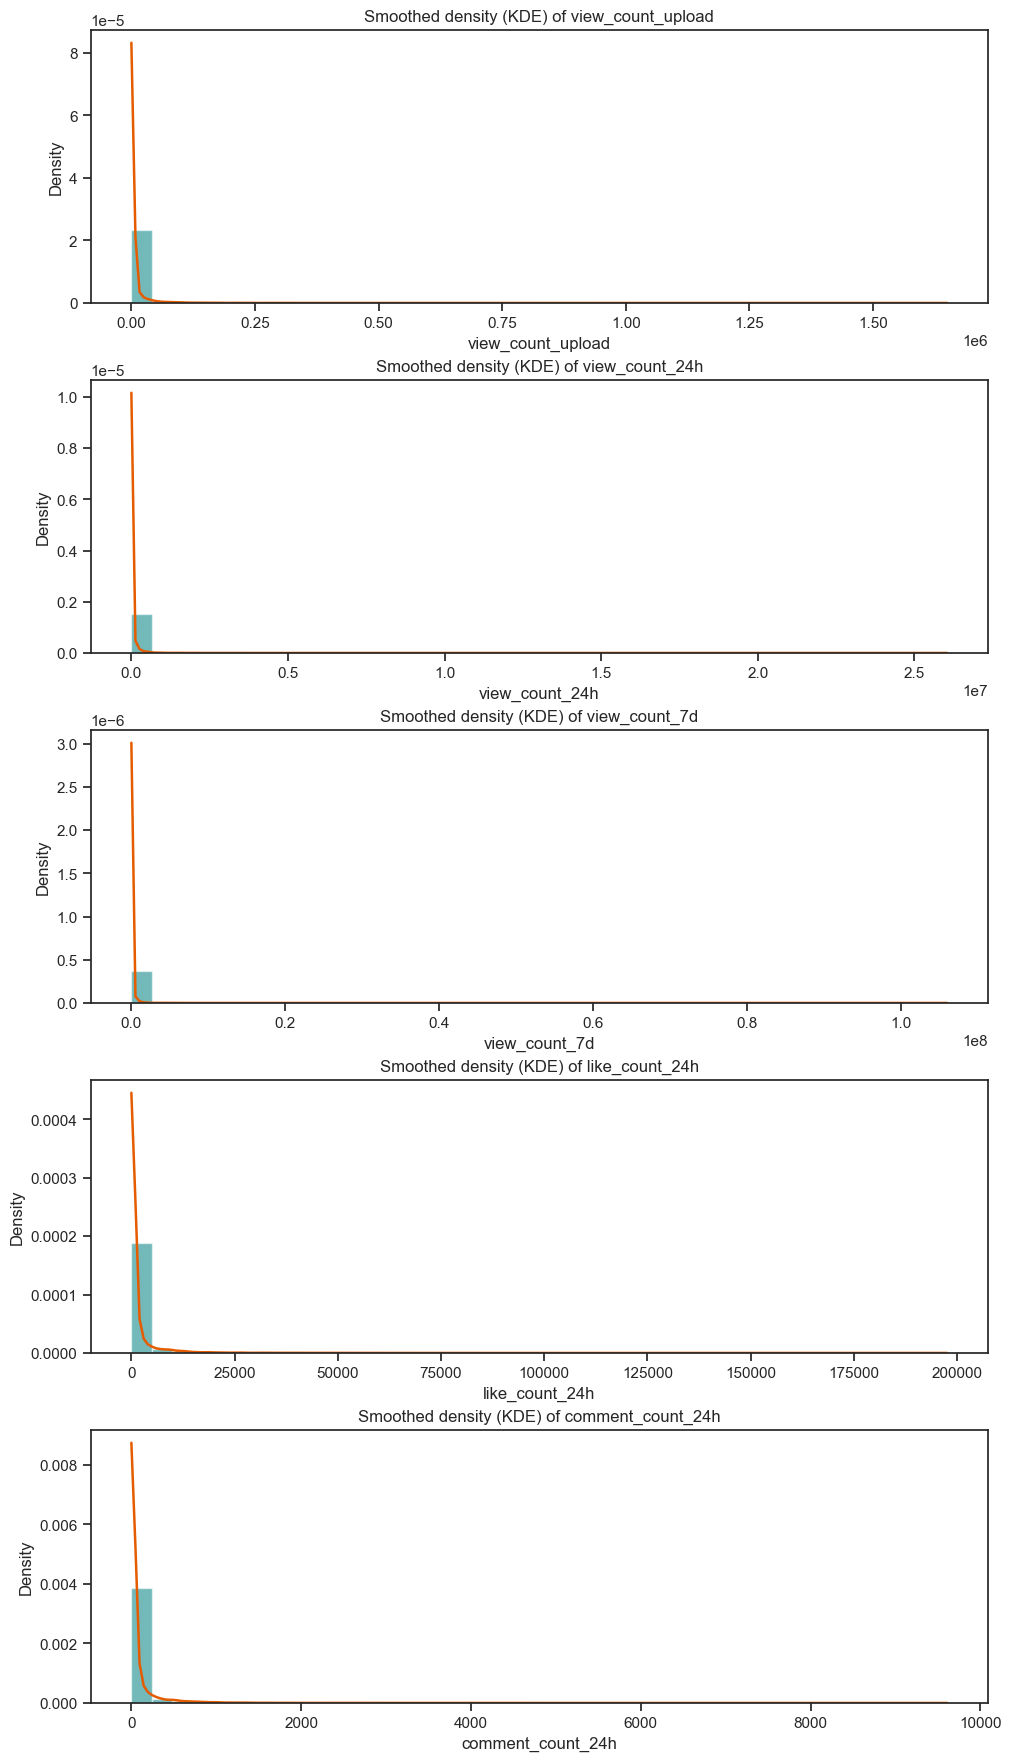

In [9]:
# plot_kde_distributions() returns one (fig, axes, cols) per page of priority
# features; label each subplot here.
for page, (fig, axes, cols) in enumerate(eda.plot_kde_distributions(run), start=1):
    for ax, col in zip(axes, cols):
        ax.set_title(f"Smoothed density (KDE) of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
    eda.save_fig(fig, fig_path("02_engagement_kde_distributions.png"), page=page)
    plt.show()

### Vertical segmentation — view velocity

Distribution of `view_count_24h` across content verticals. The boxplot shows
medians at very different scales per vertical — direct evidence that raw counts
are **not** comparable across content categories, which is exactly why the
pipeline normalizes against each channel's own baseline. The density overlay
exposes distributional shape differences the boxplot summary hides.

/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/src/capstone/pipeline/stages/eda.py:335: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="vertical", y=feature, palette="Set2", order=verticals_, ax=ax_box)


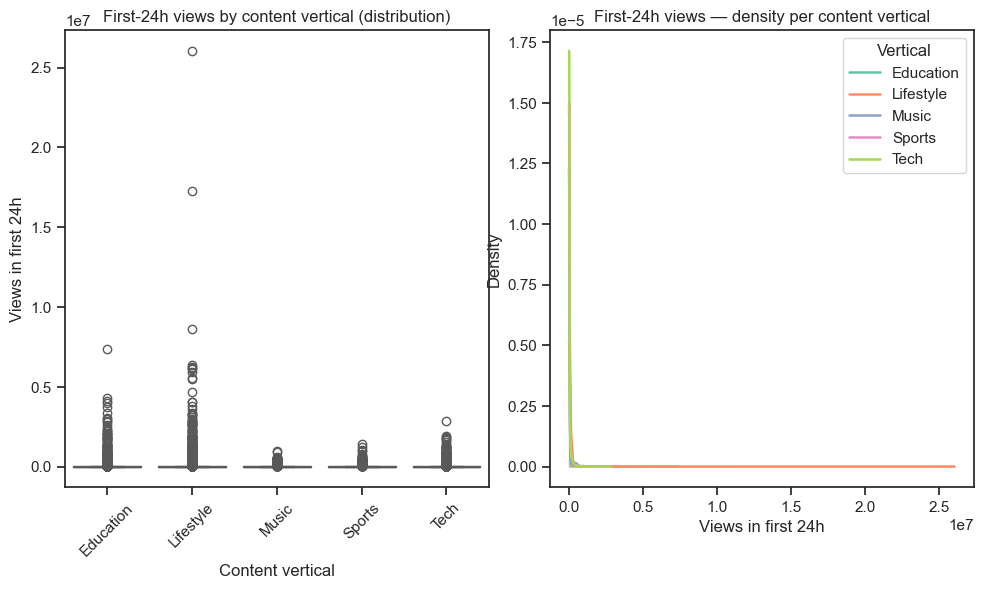

In [10]:
# plot_vertical_segmentation() returns the boxplot + density axes; label both.
fig, (ax_box, ax_density) = eda.plot_vertical_segmentation(run, feature="view_count_24h")
ax_box.set_title("First-24h views by content vertical (distribution)")
ax_box.set_xlabel("Content vertical")
ax_box.set_ylabel("Views in first 24h")
ax_density.set_title("First-24h views — density per content vertical")
ax_density.set_xlabel("Views in first 24h")
ax_density.set_ylabel("Density")
eda.save_fig(fig, fig_path("03_view_velocity.png"))
plt.show()

## Findings — raw data

- The collection pipeline yields a large pool of snapshot rows, of which the
  **complete-triplet** subset (videos observed at upload, 24h, and 7d) is the
  modelable population. The drop from raw rows to triplets is expected and
  handled structurally, not by imputation.
- `df_clean` is clean by construction: no nulls and effectively unique
  `video_id`s. No imputation is required.
- Raw engagement metrics are heavily right-skewed (power-law) and not comparable
  across verticals — motivating both the **channel-relative target** and the
  **normalized/ratio features** introduced downstream.

**Next:** [02 · Feature engineering + engineered-data EDA](./02_feature_engineering_eda.ipynb).